In [ ]:
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)

In [ ]:
from tensorflow.keras.datasets import mnist
import numpy as np

(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Flatten images like OpenML does
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

# Combine to match OpenML's full dataset
X = np.vstack([X_train, X_test])
y = np.concatenate([y_train, y_test]).astype(str)

print(X.shape, y.shape)

(70000, 784) (70000,)


In [ ]:
"""mnist = fetch_openml(name="mnist_784", as_frame=False, version=1)

X, y = mnist.data, mnist.target

print(f"Data: {X}, Targets: {y}")
print(f"Shapes: {X.shape}, {y.shape}")
"""

'mnist = fetch_openml(name="mnist_784", as_frame=False, version=1)\n\nX, y = mnist.data, mnist.target\n\nprint(f"Data: {X}, Targets: {y}")\nprint(f"Shapes: {X.shape}, {y.shape}")\n'

This is basically 70k pictures in grey scale of hand written digits, with their annotated digit they wanted to draw. Each picture is 784 pixels, which is 28x28. Let's plot one of those:

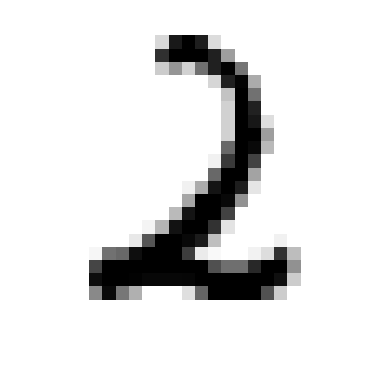

2


In [ ]:
def plot_digit(image_data):
    image = image_data.reshape(28, 28) # reshape as matrix
    plt.imshow(image, cmap="binary")
    plt.axis("off")

plot_digit(X[122])
plt.show()
print(y[122])


For now, we can train a binary classifier that only detects 5. The MNIST dataset is already split in test and train, the first 60k are train, and the latter 10k are test. It is also already shuffled.

In [ ]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]
y_test_5 = (y_test == '5')
y_train_5 = (y_train == '5')

In [ ]:
from sklearn.linear_model import SGDClassifier

classifier = SGDClassifier(random_state=42, n_jobs=3)
classifier.fit(X_train, y_train_5)

SGDClassifier(n_jobs=3, random_state=42)

In [ ]:
classifier.predict([X[0]])

array([ True])

Seems like it got it correct! Let's evaluate the model.

In [ ]:
from sklearn.model_selection import cross_val_score

cross_val_score(classifier, X_train, y_train_5, scoring="accuracy", cv=3, n_jobs=2)

array([0.95035, 0.96035, 0.9604 ])

95% accuracy? Suspicious. Let's try a dummy classifier, which basically classifies every single image in the most common class (in this case it is non-5).

In [ ]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier()
dummy.fit(X_train, y_train_5)

DummyClassifier()

In [ ]:
cross_val_score(dummy, X_train, y_train_5, scoring="accuracy", cv=3, n_jobs=3)

array([0.90965, 0.90965, 0.90965])

Basically someone guessing always the same thing gets it right 90% of the time. Not good right? Accuracy in this case is not a good metric: it is not good for **skewed** datasets (one class is more frequent than the other). A much better way is to look at the **confusion matrix**. For now, we just see how to implement a custom cross validation algorithm, since we may need more control over what the scikit learn API offers.

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=3) # could add shuffle=True if dataset was not already shuffled

for train_idx, test_idx in skfolds.split(X_train, y_train_5):
  clone_classifier = clone(classifier)

  # construct fold
  X_train_folds, X_test_folds = X_train[train_idx], X_train[test_idx]
  y_train_folds, y_test_folds = y_train_5[train_idx], y_train_5[test_idx]

  # evaluate on test
  clone_classifier.fit(X_train_folds, y_train_folds)
  y_pred = clone_classifier.predict(X_test_folds)
  n_correct = sum(y_pred == y_test_folds)
  print(n_correct / len(y_pred))

0.95035
0.96035
0.9604


Let's first get the predictions for the k-folds:

In [ ]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(classifier, X_train, y_train_5, cv=3, n_jobs=3)

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_train_5, y_train_pred)
cm

array([[53892,   687],
       [ 1891,  3530]])

So we get some errors on FP and FN. Maybe we could look into precision and recall:

In [ ]:
from sklearn.metrics import precision_score, recall_score

precision_score(y_train_5, y_train_pred)

0.8370879772350012

In [ ]:
recall_score(y_train_5, y_train_pred)

0.6511713705958311

Does not look that good now huh? It only detects 65% of the 5s. We could combine them both in the F1 score:

In [ ]:
from sklearn.metrics import f1_score

f1_score(y_train_5, y_train_pred)

0.7325171197343847

# Precision/Recall trade-off
You saw on the theory sheet how we can manipulate the threshold of decision for the classifier in order to get better results on the precision/recall tradeoff.
Let's see how to do it:

In [ ]:
y_scores = classifier.decision_function([X[0]])
y_scores

array([2164.22030239])

In [ ]:
threshold = 0
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([ True])

This is normal, as SGDClassifier *always* uses a threshold of 0. Let's see what happens when we modify this:

In [ ]:
threshold = 3000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

Since we get less true positives now, we decrease recall. We can decide which threshold to use with `cross_val_predict` in this way:

In [ ]:
y_scores = cross_val_predict(classifier, X_train, y_train_5, cv=3, n_jobs=3, method="decision_function")

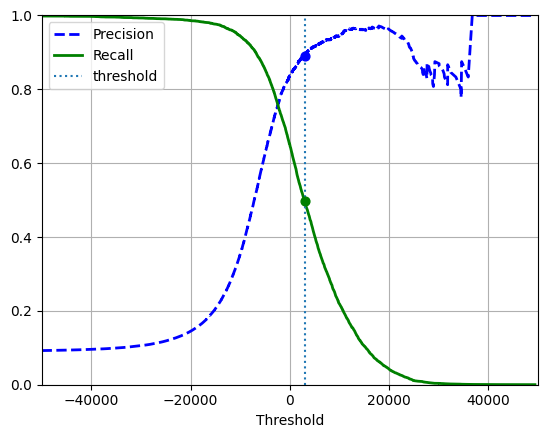

In [ ]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

idx = np.argmin(np.abs(thresholds - threshold))

plt.plot(thresholds, precisions[:-1], 'b--', label='Precision', linewidth=2)
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall', linewidth=2)

plt.xlim(-50000, 50000)
plt.ylim(0.0, 1.001)

plt.xlabel("Threshold")

plt.vlines(threshold, 0, 1.0, linestyles='dotted', label='threshold')
plt.legend(loc="upper left")
plt.scatter(thresholds[idx], precisions[idx], color='blue', s=40, zorder=5)
plt.scatter(thresholds[idx], recalls[idx], color='green', s=40, zorder=5)

plt.grid()
plt.show()

Which yields a precision of around 90% and a recall of 50%. We can also plot just against recall, and find the "elbow" in that curve:

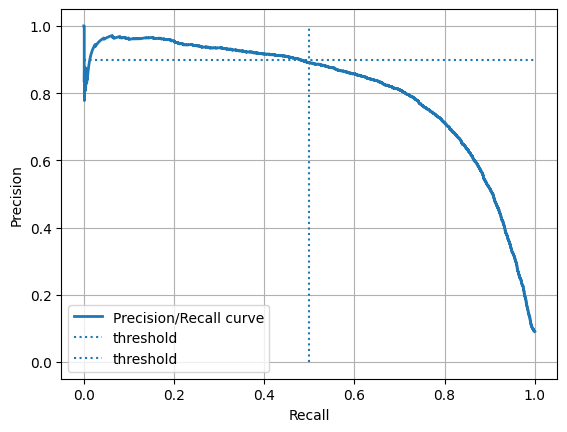

In [ ]:
plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.vlines(0.5, 0, 1.0, linestyles='dotted', label='threshold')
plt.hlines(0.9, 0, 1.0, linestyles='dotted', label='threshold')

plt.legend(loc="lower left")
plt.grid()
plt.show()

Precision starts falling sharply at around 80% recall, so we would probably take something like 60%/65% recall. We could even achieve a 90% precision model:

In [ ]:
idx_90_precision = (precisions >= 0.9).argmax()
threshold_90_precision = thresholds[idx_90_precision]
threshold_90_precision

np.float64(3370.0194991439557)

In [ ]:
y_train_pred_90 = (y_scores >= threshold_90_precision)
precision_score(y_train_5, y_train_pred_90)

0.9000345901072293

In [ ]:
recall_score(y_train_5, y_train_pred_90)

0.4799852425751706

So basically you have a classifier with 90% precision, but with 48% recall. Good enough? Depends on the use case.

# The ROC curve

We can use sklearn to also get data for the ROC curve, as you seen in the theory part:

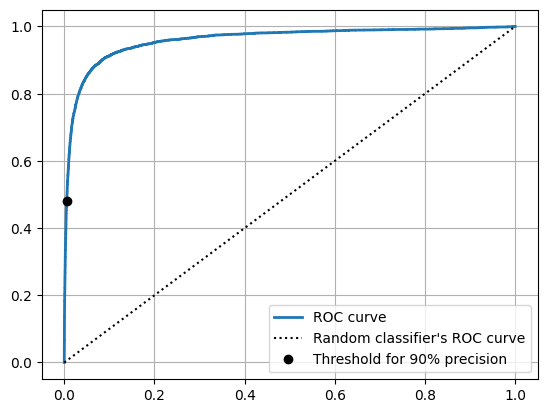

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

idx_for_threshold_at_90 = (thresholds <= threshold_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% precision")

plt.legend(loc="lower right")
plt.grid()
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_train_5, y_scores)

np.float64(0.9604938554008616)

In this case our positive class was rarer than the negative, so given the AUC score we might think this is a good classifier, but in fact it is not that good.

#Experiments

Now let's try different ways to train a model on this dataset.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state=42)
y_probs_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3, n_jobs=3, method="predict_proba")
y_probs_forest[:2]

array([[0.11, 0.89],
       [0.99, 0.01]])

so for the classifier the first image is a 5 with 89% probability, and the second one is not a 5 with 99% probability.

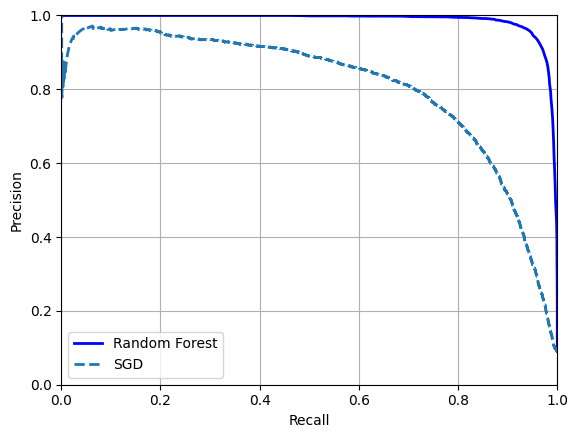

In [ ]:
y_scores_forest = y_probs_forest[:, 1]
precisions_forest, recalls_forest, thresholds_forest = precision_recall_curve(y_train_5, y_scores_forest)

plt.plot(recalls_forest, precisions_forest, "b-", linewidth=2, label="Random Forest")
plt.plot(recalls, precisions, "--", linewidth=2, label="SGD")

plt.xlim(0.0, 1.0)
plt.ylim(0.0, 1.001)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left")
plt.grid()
plt.show()


In [ ]:
y_train_probs_forest = y_probs_forest[:, 1] >= 0.5
roc_auc_score(y_train_5, y_train_probs_forest)

np.float64(0.9358174809192218)

In [ ]:
f1_score(y_train_5, y_train_probs_forest)

0.9274509803921569

In [ ]:
precision_score(y_train_5, y_train_probs_forest)

0.9897468089558485

In [ ]:
recall_score(y_train_5, y_train_probs_forest)

0.8725327430363402

# Multiclass classification

On the theory we see the different techniques of multiclass classification. Scikit-learn automatically detects when you want to use a binary classification algorithm for a multiclass classification task, and it automatically runs OvR or OvO. Let's try this with SVC:

In [ ]:
from sklearn.svm import SVC

svm_clf = SVC(random_state=42)
svm_clf.fit(X_train[:2000], y_train[:2000])

SVC(random_state=42)

In [ ]:
svm_clf.predict([X[122]])

array(['2'], dtype='<U3')

This actually made 45 predictions, one per pair of classes, and it selected the class that won the most duels. We can see the decision function to check the score of each instance:

In [ ]:
digit_scores = svm_clf.decision_function([X[0]])
digit_scores.round(2)

array([[ 3.79,  0.73,  6.06,  8.3 , -0.29,  9.3 ,  1.75,  2.77,  7.21,
         4.82]])

In [ ]:
class_id = digit_scores.argmax()
class_id

np.int64(5)

5 won with a score of 9.3. When a classifier is trained, it stores the target classes in the `classes_` attribute. We can also use other classifiers with other strategies:

In [ ]:
from sklearn.multiclass import OneVsRestClassifier

ovr_clf = OneVsRestClassifier(SVC(random_state=42))
ovr_clf.fit(X_train[:2000], y_train[:2000])

OneVsRestClassifier(estimator=SVC(random_state=42))

In [ ]:
ovr_clf.predict([X[0]])

array(['5'], dtype='<U1')

Let's try an SGDClassifier:

In [ ]:
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train)

SGDClassifier(random_state=42)

In [ ]:
sgd_clf.predict([X[0]])

array(['3'], dtype='<U1')

Mistake. We can see what happened with the decision function:

In [ ]:
sgd_clf.decision_function([X[0]])

array([[-31893.03095419, -34419.69069632,  -9530.63950739,
          1823.73154031, -22320.14822878,  -1385.80478895,
        -26188.91070951, -16147.51323997,  -4604.35491274,
        -12050.767298  ]])

The model is unsure about all the classes. Let's evaluate the classifier:

In [ ]:
cross_val_score(sgd_clf, X_train, y_train, scoring="accuracy", cv=3, n_jobs=2)

array([0.87365, 0.85835, 0.8689 ])

We can also scale the features to yield some slightly better results:

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_transformed = scaler.fit_transform(X_train.astype("float64"))
cross_val_score(sgd_clf, X_transformed, y_train, scoring="accuracy", cv=3, n_jobs=2)

array([0.8983, 0.891 , 0.9018])

# Error analysis

Suppose we already scanned for the best models, data preparation etc. We want then to analyze the mistakes the model makes.
First we look at the confusion matrix.

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

y_train_pred = cross_val_predict(sgd_clf, X_transformed, y_train, cv=3, n_jobs=2, verbose=2)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred)
plt.show()

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.


KeyboardInterrupt: 

# Multilabel classification

Sometimes you want your classifier to recognize multiple classes. We will use a KNN which natively supports multilabel prediction, to detect wether a number is large (>= 7) or not, and odd or not.

In [ ]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

y_train_large = (y_train >= '7')
y_train_odd = (y_train.astype('int8') % 2 == 1)
y_multilabel = np.c_[y_train_large, y_train_odd]

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)

KNeighborsClassifier()

In [ ]:
knn_clf.predict([X[0]])

array([[False,  True]])

Correct, as 5 is odd but not large.

To evaluate the performances of this classifier we have different ways. We could calculate the F1 score of each label, and then computing the average score.

In [ ]:
y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3, n_jobs=2, verbose=2)
f1_score(y_multilabel, y_train_knn_pred, average="macro")

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.


KeyboardInterrupt: 

This assumes each label is equally important, which is not the case in many instances. One another way is switching the average based on the support (the number of instances in the dataset). To do this we just change `average` to `"weighted"`

If you want to use a classifier which does not support natively the multilabel, like SVC, you could train one SVC per label, even though you might not capture dependencies between labels (a large number is twice as likely to be odd). To solve this, we can use a classifier chain with cross validation, which takes into account all the other model predictions before making a new one.

In [ ]:
from sklearn.multioutput import ClassifierChain

chain_clf = ClassifierChain(SVC(), cv=3, random_state=42)
chain_clf.fit(X_train[:2000], y_multilabel[:2000])

ClassifierChain(base_estimator=SVC(), cv=3, random_state=42)

In [ ]:
chain_clf.predict([X[0]])

array([[0., 1.]])

# Multioutput classification

It is a type of multilabel classification where each label can have more than two classes. We can take an example of a system that removes noise from images. The output is a set of pixels where each pixel varies from 0 to 255.

First we create the training and test set by adding noise to the original images in MNIST.

In [ ]:
noise = np.random.randint(0, 100, (len(X_train), 784))
X_train_mod = X_train + noise

noise = np.random.randint(0, 100, (len(X_test), 784))
X_test_mod = X_test + noise

y_train_mod = X_train
y_test_mod = X_test

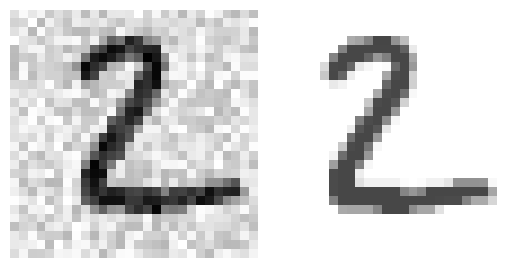

In [ ]:
image = np.hstack((X_test_mod[1].reshape(28, 28), y_test_mod[1].reshape(28, 28))).reshape(28, 56) # reshape as matrix
plt.imshow(image, cmap="binary")
plt.axis("off")
plt.show()

In [ ]:
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train_mod, y_train_mod)

KNeighborsClassifier()

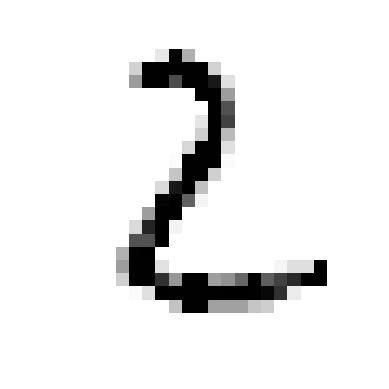

In [ ]:
clean_digit = knn_clf.predict([X_test_mod[1]])
plot_digit(clean_digit)
plt.show()

# Exercises

## 1.

Try to build a classifier for the MNIST dataset that achieves over 97% accuracy
on the test set. Hint: the KNeighborsClassifier works quite well for this task;
you just need to find good hyperparameter values (try a grid search on the
weights and n_neighbors hyperparameters).

First I just try the normal KNeighborsClassifier.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
knn_clf.score(X_test, y_test)

0.9688

Then I try to optimize the hyperparameters using the grid search:

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {'weights': ['uniform', 'distance'], 'n_neighbors': [3, 4, 5, 6]}
grid_search = GridSearchCV(knn_clf, param_grid)
grid_search.fit(X_train[:10000], y_train[:10000])

GridSearchCV(estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [3, 4, 5, 6],
                         'weights': ['uniform', 'distance']})

In [ ]:
grid_search.best_params_

{'n_neighbors': 4, 'weights': 'distance'}

Then, we fit on the whole dataset:

In [ ]:
knn_clf = KNeighborsClassifier(n_neighbors=4, weights='distance')
knn_clf.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=4, weights='distance')

In [ ]:
knn_clf.score(X_test, y_test)

0.9714

## 2

Write a function that can shift an MNIST image in any direction (left, right, up,
or down) by one pixel. You can use the `shift()` function from the `scipy.ndimage.interpolation` module. For example,
`shift(image, [2, 1], cval=0)` shifts the image two pixels down and one pixel to the right. Then, for each image in the training set, create four
shifted copies (one per direction) and add them to the training set. Finally, train
your best model on this expanded training set and measure its accuracy on the
test set. You should observe that your model performs even better now! This
technique of artificially growing the training set is called data augmentation or
training set expansion.

In [141]:
from scipy.ndimage import shift

def shift_image(image, dx, dy):
  reshaped_image = image.reshape(28, 28)
  return shift(reshaped_image, [dy, dx], cval=0).reshape(-1)

In [142]:
X_train_augmented = [image for image in X_train]
y_train_augmented = [label for label in y_train]

for dx, dy in [(1, 0), (0, 1), (-1, 0), (0, -1)]:
  for image, label in zip(X_train, y_train):
    shifted_image = shift_image(image, dx, dy)
    X_train_augmented.append(shifted_image)
    y_train_augmented.append(label)

X_train_augmented = np.array(X_train_augmented)
y_train_augmented = np.array(y_train_augmented)

In [143]:
idx_permutation = np.random.permutation(len(X_train_augmented))
X_train_augmented = X_train_augmented[idx_permutation]
y_train_augmented = y_train_augmented[idx_permutation]

Then from previous ex:

In [144]:
knn_clf = KNeighborsClassifier(n_neighbors=4, weights='distance')
knn_clf.fit(X_train_augmented, y_train_augmented)

KNeighborsClassifier(n_neighbors=4, weights='distance')

In [145]:
knn_clf.score(X_test, y_test)

0.9763